# Задание 3. NLP
## Задача 1 5 баллов
- Напишите токенайзенр на основе BPE, используя претокенизацию и специальные токены. Можете использовать паттерны претокенизации открытых моделей, указав источник. 
- Обучите свой токенизатор на своем корпусе, токенизируйте тексты, не совпадающие с использованным для обучения. 
- Определите коэффициент сжатия (число токенов к количеству байт/символов), среднее количество токенов на слово, среднее количество токенов на слово для топ 10% частотных слов. Ответьте на вопрос, отличается ли эффективность для разных доменов?
- Постройте кривую: размер словаря vs compression ratio
- Определите, какая часть токенов не использовалась ни разу при токенизации [корпуса стихотворений Пушкина](https://dataverse.pushdom.ru/dataset.xhtml?persistentId=doi:10.31860/openlit-2023.8-C005)


In [1]:
import pandas as pd
import re
import os

from collections import Counter
import matplotlib.pyplot as plt

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from transformers import GPT2LMHeadModel

from typing import List, Dict, Tuple, Set



In [2]:
#Anime corpuses
#https://www.kaggle.com/datasets/theodaimones888/russian-anime-reviews-dataset
#https://www.kaggle.com/datasets/assilsigma/findaminenet-russian-anime-dataset

#Maybe starting at 11:30 PM is a bad idea, i dont know)) It will be fun ;)

anime_reviews = pd.read_csv("/home/kalisto/Documents/spbu_dl_2025/data/ANIME/Anime_reviews_RU.csv")
anime_description = pd.read_csv("/home/kalisto/Documents/spbu_dl_2025/data/ANIME/extended_anime.csv")

anime_description = anime_description["Description"]
anime_reviews = anime_reviews["Text"]

anime_description = anime_description.str.cat()
anime_reviews = anime_reviews.str.cat()

In [3]:
print(anime_reviews[:500])
print(anime_description[:500])

после первой арки несколько разочаровался, ожидал большего. еще пять раз смотреть одно и то же с разными героинями как-то желания нет. отложу просмотр остальных серий на потом. :lonely:Концовка какая-то мутная, ничего не понял. Надеюсь на второй сезон.Само аниме сильно понравилось, побольше бы таких. Засилье школьных эччи удручает.Что тут сказать? Никакого сравнени я с Seed, хоть и пытается ему подражать... Банаджер вообще не выдерживает никакого сравнения с обаятельным, харизматичным, молчаливы
«Ходячий замок» — полнометражное аниме, выпущенное студией «Ghibli» в 2004 году. Создан японским режиссёром Хаяо Миядзаки по мотивам одноимённого сказочного романа английской писательницы Дианы Уинн Джонс. Действие фильма происходит в параллельном мире Европы конца XIX-го века, где магия идёт рука об руку с техническим прогрессом. Скромная жизнь шляпницы Софи полностью изменяется, когда в окрестностях её города появляется ходячий замок таинственного волшебника Хаула, известного своими «похищени

In [4]:
anime_reviews = re.sub(r'[^a-zA-Zа-яА-Я0-9\s.,!?;:\-—()"\'\[\]{}]', '', anime_reviews)
anime_description = re.sub(r'[^a-zA-Zа-яА-Я0-9\s.,!?;:\-—()"\'\[\]{}]', '', anime_description)

In [5]:
print(anime_reviews[:500])
print(anime_description[:500])

после первой арки несколько разочаровался, ожидал большего. еще пять раз смотреть одно и то же с разными героинями как-то желания нет. отложу просмотр остальных серий на потом. :lonely:Концовка какая-то мутная, ничего не понял. Надеюсь на второй сезон.Само аниме сильно понравилось, побольше бы таких. Засилье школьных эччи удручает.Что тут сказать? Никакого сравнени я с Seed, хоть и пытается ему подражать... Банаджер вообще не выдерживает никакого сравнения с обаятельным, харизматичным, молчаливы
Ходячий замок — полнометражное аниме, выпущенное студией Ghibli в 2004 году. Создан японским режиссром Хаяо Миядзаки по мотивам одноимнного сказочного романа английской писательницы Дианы Уинн Джонс. Действие фильма происходит в параллельном мире Европы конца XIX-го века, где магия идт рука об руку с техническим прогрессом. Скромная жизнь шляпницы Софи полностью изменяется, когда в окрестностях е города появляется ходячий замок таинственного волшебника Хаула, известного своими похищениями девич

In [6]:
print(len(anime_reviews))
print(len(anime_description))

95064384
3475123


In [7]:
anime_reviews = anime_reviews[:3475123]
anime_description = anime_description[:3475123]
print(len(anime_reviews))

3475123


##### Напишите токенайзенр на основе BPE, используя претокенизацию и специальные токены. Можете использовать паттерны претокенизации открытых моделей, указав источник. 

In [ ]:
# TODO ADD handmade bpe
class BPE():
    def __init__(self, vocab_size: int):
        self.merges = {}
        self.special_tokens = {}
        self.vocab = self._build_vocab()
        self.vocab_size = vocab_size

    def _build_vocab(self):
        # дополнительный метод, который помогает построить словарь.
        # начальный словарь - содержит все возможные символы по одному
        vocab = {idx: bytes([idx]) for idx in range(256)} 
        # конкатенируем байты из наших мерджей
        for (p0, p1), idx in self.merges.items():
            vocab[idx] = vocab[p0] + vocab[p1]

        # не забываем про <bos>,<eos>, <|user|>, <think> и тд.
        for special, idx in self.special_tokens.items():
            vocab[idx] = special.encode("utf-8")
        return vocab

    def get_stats(self, ids: list[int]) -> dict[tuple[int, int], int]:
        """counts pairs in text. Note that consecutive pairs overlap (if you have abc, pairs are ab. bc)"""
        # copy code here 
        return counts

    def merge(self, ids: list[int], pair: tuple[int, int], new_id: int) -> list[int] :
        """
        Merges all the occurencies of pair in list of ids int one new_id.
        """
        # copy code here 
        return new_ids

    def fit(self, dataset: list[int], verbose: bool = True) -> None:
        # copy code here 
        for i in range(num_merges):
            # copy code here
            if verbose:
                print(f"New merged pair is: {next_pair} -> {first_merge_id + i}")
                
        self.vocab = self._build_vocab()

    def encode(self, text: str) -> list[int]:
        """ Get sequence of token ids using merge dict
        """
        # your code - there are several ways to encode sequence
        # you can reuse stats and merge code (obviously if there is more than two tokens)
        # after get of stats, you need to find first pair suitable for merges in merges dict:
        # min(stats, key=lambda x: self.merges.get(x, float("inf")))
        # In that case, if you used all possible merges from dict, return encoded sequence.
        
        return tokens


    def decode(self, token_ids: list[int]) -> str:
        """  
        From list of ids we get string. Use b"", decode("utf-8"). Use "replace" as param of decode.
        """
        return # your code 

In [8]:
corpus = anime_reviews

tokenizer_anime_reviews = Tokenizer(BPE(unk_token="[UNK]"))

tokenizer_anime_reviews.pre_tokenizer = ByteLevel()
tokenizer_anime_reviews.decoder = ByteLevelDecoder()

#tokenizer_anime_reviews.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    show_progress=False,
    initial_alphabet=[]
)

tokenizer_anime_reviews.train_from_iterator([corpus], trainer=trainer)

tokenizer_vocab_anime_reviews = tokenizer_anime_reviews.get_vocab()
print(f"Vocabulary size: {len(tokenizer_vocab_anime_reviews)}")
print(f"Sample tokens: {list(tokenizer_vocab_anime_reviews.keys())[:20]}")

#tokenizer_anime_reviews.save("anime_tokenizer.json")

sample_text = "Один воин вышел в лес"
encoding = tokenizer_anime_reviews.encode(sample_text)
print(f"\nOriginal: {sample_text}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

decoded = tokenizer_anime_reviews.decode(encoding.ids)
print(f"Decoded: {decoded}")

Vocabulary size: 5000
Sample tokens: ['ÑĭÐ²Ð°Ð»', 'ĠÑĪÐµÐ´ÐµÐ²', 'ĠÐ¸Ð´Ð¸Ð¾ÑĤ', 'ĠÑģÐ°Ð¼Ð¸', 'ĠÐ²Ð¼ÐµÑģÑĤÐ¾', 'ĠÑģÐ¸Ð¼', 'ÑĩÐµ', 'ĠÐŀÐ½', 'Ð°Ð»ÑĮÐ½Ð°Ñı', 'ÑĥÑİÑīÐ¸Ñħ', '))', 'ĠÐ¶ÐµÐ»Ð°Ð½Ð¸Ñı', 'ĠÐ´ÑĢÐ¾Ð¿Ð½ÑĥÑĤÑĮ', 'ĠÐºÐ¾Ð½ÑĦ', 'ĠÐ»Ð¸Ð½Ð¸Ð¸', 'Ð½Ð°ÑĩÐ°Ð»Ðµ', 'ĠÑģÐ¸ÑĤÑĥÐ°ÑĨÐ¸Ð¸', 'ĠÐ±Ð°Ð½', 'Ð°ÑİÑīÐ¸Ð¼Ð¸', 'Ð¸Ð²Ð°Ñİ']

Original: Один воин вышел в лес
Tokens: ['ĠÐŀ', 'Ð´Ð¸Ð½', 'ĠÐ²Ð¾', 'Ð¸Ð½', 'ĠÐ²ÑĭÑĪÐµÐ»', 'ĠÐ²', 'ĠÐ»ÐµÑģ']
IDs: [356, 887, 437, 225, 3848, 171, 4918]
Decoded:  Один воин вышел в лес


In [9]:
corpus = anime_description

tokenizer_anime_description = Tokenizer(BPE(unk_token="[UNK]"))

tokenizer_anime_description.pre_tokenizer = ByteLevel()
tokenizer_anime_description.decoder = ByteLevelDecoder()

#tokenizer_anime_description.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    show_progress=False,
    initial_alphabet=[]
    
)

tokenizer_anime_description.train_from_iterator([corpus], trainer=trainer)

tokenizer_vocab_anime_description = tokenizer_anime_description.get_vocab()
print(f"Vocabulary size: {len(tokenizer_vocab_anime_description)}")
print(f"Sample tokens: {list(tokenizer_vocab_anime_description.keys())[:20]}")

#tokenizer_anime_description.save("anime_tokenizer.json")

sample_text = "Один воин вышел в лес"
encoding = tokenizer_anime_description.encode(sample_text)
print(f"\nOriginal: {sample_text}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

decoded = tokenizer_anime_description.decode(encoding.ids)
print(f"Decoded: {decoded}")

Vocabulary size: 5000
Sample tokens: ['ĠÐ', 'Ð¾ÑĢÑĤ', 'ĠÑģÑĥÐ´ÑĮÐ±Ñĥ', 'ÑģÑĤÑĢÐ¾Ð²', 'ĠFindAnimeÐĴ', 'ĠÐ¿ÑĥÐ±', 'Ð»Ð°Ñģ', 'Ġ20', 'ÐºÐ¾Ð³Ð¾', 'ÑįÑĤÐ¾Ð¼Ñĥ', 'ĠÑĥÐ¶Ðµ', 'ĠÐ¿ÑĢÐ¸Ð·Ð½', 'ĠÐļÐ¾Ñģ', 'ÑĮÐ¼Ñĭ', 'ĠÐ¢Ð¾Ð»ÑĮÐºÐ¾', 'ĠÐĹÐµÐ¼Ð»Ñİ', 'ĠÐ¿Ð¾ÑıÐ²Ð»ÑıÑİÑĤÑģÑı', 'ou', 'ĠÐ¾Ð±ÑĥÑĩ', 'ĠÑĥÑĩÐ¸ÑĤÐµÐ»Ñı']

Original: Один воин вышел в лес
Tokens: ['ĠÐŀÐ´Ð¸Ð½', 'ĠÐ²Ð¾Ð¸Ð½', 'ĠÐ²ÑĭÑĪ', 'ÐµÐ»', 'ĠÐ²', 'ĠÐ»ÐµÑģ']
IDs: [4017, 4110, 2595, 200, 166, 2193]
Decoded:  Один воин вышел в лес


In [52]:
all_tokens_reviews = []
for text in anime_reviews.split('\n'):
    encoded = tokenizer_anime_reviews.encode(text)
    all_tokens_reviews.extend(encoded.tokens)

all_tokens_description = []
for text in anime_description.split('\n'):
    encoded = tokenizer_anime_description.encode(text)
    all_tokens_description.extend(encoded.tokens)

token_counts_reviews = Counter(all_tokens_reviews)
token_counts_description = Counter(all_tokens_description)

most_common_reviews = token_counts_reviews.most_common(20)
most_common_description = token_counts_description.most_common(20)

tokens_reviews, counts_reviews = zip(*most_common_reviews)
tokens_description, counts_description = zip(*most_common_description)

unique_tokens_reviews = list(set(all_tokens_reviews))
unique_tokens_reviews.sort(key=len, reverse=True)
longest_tokens_reviews = unique_tokens_reviews[:20]
lengths_longest_reviews = [len(t) for t in longest_tokens_reviews]

unique_tokens_description = list(set(all_tokens_description))
unique_tokens_description.sort(key=len, reverse=True)
longest_tokens_description = unique_tokens_description[:20]
lengths_longest_description = [len(t) for t in longest_tokens_description]

fig, axs = plt.subplots(2, 2, figsize=(18,12))

axs[0,0].bar(tokens_reviews, counts_reviews)
axs[0,0].set_xticks(range(len(tokens_reviews)))
axs[0,0].set_xticklabels(tokens_reviews, rotation=45)
axs[0,0].set_xlabel("Tokens")
axs[0,0].set_ylabel("Frequency")
axs[0,0].set_title("Top 20 Most Frequent Tokens (Reviews)")

axs[0,1].bar(tokens_description, counts_description)
axs[0,1].set_xticks(range(len(tokens_description)))
axs[0,1].set_xticklabels(tokens_description, rotation=45)
axs[0,1].set_xlabel("Tokens")
axs[0,1].set_ylabel("Frequency")
axs[0,1].set_title("Top 20 Most Frequent Tokens (Description)")

axs[1,0].bar(longest_tokens_reviews, lengths_longest_reviews)
axs[1,0].set_xticks(range(len(longest_tokens_reviews)))
axs[1,0].set_xticklabels(longest_tokens_reviews, rotation=45)
axs[1,0].set_xlabel("Tokens")
axs[1,0].set_ylabel("Token Length")
axs[1,0].set_title("Top 20 Longest Tokens (Reviews)")

axs[1,1].bar(longest_tokens_description, lengths_longest_description)
axs[1,1].set_xticks(range(len(longest_tokens_description)))
axs[1,1].set_xticklabels(longest_tokens_description, rotation=45)
axs[1,1].set_xlabel("Tokens")
axs[1,1].set_ylabel("Token Length")
axs[1,1].set_title("Top 20 Longest Tokens (Description)")


plt.tight_layout()
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

In [11]:
encoding = tokenizer_anime_description.encode(anime_reviews[:50])
print(f"\nOriginal: {anime_reviews[:50]}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

encoding = tokenizer_anime_reviews.encode(anime_description[:50])
print(f"\nOriginal: {anime_description[:50]}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")


Original: после первой арки несколько разочаровался, ожидал 
Tokens: ['ĠÐ¿Ð¾ÑģÐ»Ðµ', 'ĠÐ¿ÐµÑĢÐ²Ð¾Ð¹', 'ĠÐ°ÑĢ', 'ÐºÐ¸', 'ĠÐ½ÐµÑģÐºÐ¾Ð»ÑĮÐºÐ¾', 'ĠÑĢÐ°Ð·', 'Ð¾Ñĩ', 'Ð°ÑĢÐ¾Ð²', 'Ð°Ð»ÑģÑı', ',', 'ĠÐ¾Ð¶Ð¸Ð´', 'Ð°Ð»', 'Ġ']
IDs: [634, 2410, 896, 355, 1699, 335, 308, 1895, 872, 10, 2612, 204, 112]

Original: Ходячий замок — полнометражное аниме, выпущенное с
Tokens: ['ĠÐ¥', 'Ð¾Ð´', 'ÑıÑĩ', 'Ð¸Ð¹', 'ĠÐ·Ð°Ð¼', 'Ð¾Ðº', 'ĠâĢĶ', 'ĠÐ¿Ð¾Ð»Ð½Ð¾Ð¼ÐµÑĤÑĢÐ°Ð¶', 'Ð½Ð¾Ðµ', 'ĠÐ°Ð½Ð¸Ð¼Ðµ', ',', 'ĠÐ²ÑĭÐ¿', 'ÑĥÑī', 'ÐµÐ½Ð½Ð¾Ðµ', 'ĠÑģ']
IDs: [498, 228, 3271, 287, 763, 300, 3148, 2662, 337, 283, 10, 1501, 824, 2178, 166]


##### Определите коэффициент сжатия (число токенов к количеству байт/символов), среднее количество токенов на слово, среднее количество токенов на слово для топ 10% частотных слов. Ответьте на вопрос, отличается ли эффективность для разных доменов?

Compression Ratio = число символов/число токенов
	​


In [12]:
from collections import Counter

def text_stats(text, tokenizer):
    encoding = tokenizer.encode(text)
    num_tokens = len(encoding.ids)
    words = text.split()
    num_words = len(words)
    compression_ratio = num_tokens / len(text)
    avg_tokens_per_word = num_tokens / num_words
    word_counts = Counter(words)
    top_words = set(w for w, _ in word_counts.most_common(max(1, int(len(word_counts) * 0.1))))
    avg_tokens_top10 = sum(len(tokenizer.encode(w).ids) for w in words if w in top_words) / max(1, sum(1 for w in words if w in top_words))
    print(f"Compression ratio: {compression_ratio}")
    print(f"Average tokens per word: {avg_tokens_per_word}")
    print(f"Average tokens per top 10% frequent words: {avg_tokens_top10}")

print(f"Anime_reviews with anime_reviews tokenizer")
text_stats(anime_reviews, tokenizer_anime_reviews)

print(f"\nAnime_description with anime_description tokenizer")
text_stats(anime_description, tokenizer_anime_description)


print(f"\n\nAnime_reviews with anime_description tokenizer")
text_stats(anime_reviews, tokenizer_anime_description)

print(f"\nAnime_description with anime_reviews tokenizer")
text_stats(anime_description, tokenizer_anime_reviews)


Anime_reviews with anime_reviews tokenizer
Compression ratio: 0.2821405170406918
Average tokens per word: 1.8610733592492483
Average tokens per top 10% frequent words: 1.3088429028280517

Anime_description with anime_description tokenizer
Compression ratio: 0.28992815506098635
Average tokens per word: 2.0310195656293213
Average tokens per top 10% frequent words: 1.4205187493431126


Anime_reviews with anime_description tokenizer
Compression ratio: 0.32411773626429913
Average tokens per word: 2.1379661827679413
Average tokens per top 10% frequent words: 1.5809055025318246

Anime_description with anime_reviews tokenizer
Compression ratio: 0.3296303468970739
Average tokens per word: 2.3091433939291317
Average tokens per top 10% frequent words: 1.674695133209673


##### Ответьте на вопрос, отличается ли эффективность для разных доменов?
- Судя по полученным результатам, лучше всего токенизировать на собственном трейне, что логично.
- Использование токенизатора обученного на обзорах показало лучший результат при токенизации, по сравнению с токенизатором обученном на описаниях.

##### Постройте кривую: размер словаря vs compression ratio

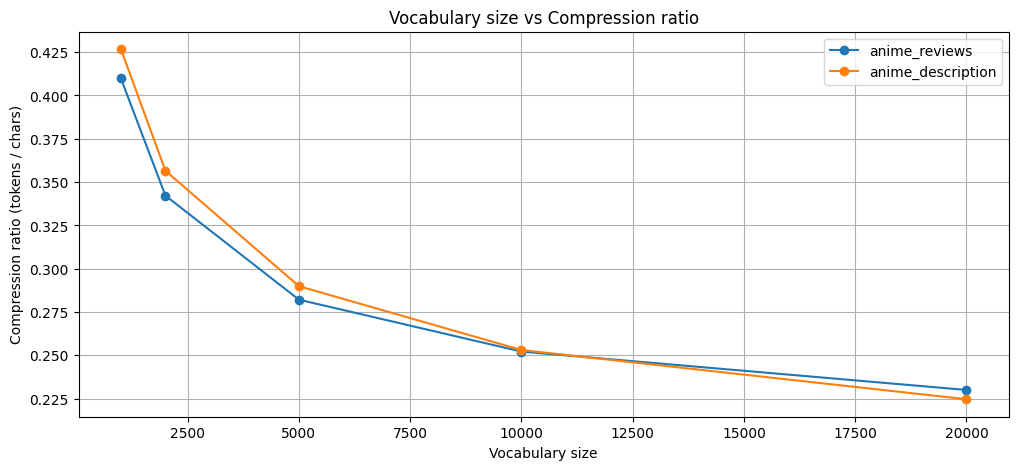

In [13]:
corpora = {
    "anime_reviews": anime_reviews,
    "anime_description": anime_description
}

vocab_sizes = [1000, 2000, 5000, 10000, 20000]

plt.figure(figsize=(12,5))

for name, corpus in corpora.items():
    compression_ratios = []
    for vocab_size in vocab_sizes:
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=False
        )
        tokenizer.train_from_iterator([corpus], trainer=trainer)
        encoding = tokenizer.encode(corpus)
        compression_ratio = len(encoding.ids) / len(corpus.replace("\n", ""))
        compression_ratios.append(compression_ratio)
    plt.plot(vocab_sizes, compression_ratios, marker='o', label=name)

plt.xlabel("Vocabulary size")
plt.ylabel("Compression ratio (tokens / chars)")
plt.title("Vocabulary size vs Compression ratio")
plt.grid(True)
plt.legend()
plt.show()

##### Определите, какая часть токенов не использовалась ни разу при токенизации [корпуса стихотворений Пушкина]

In [14]:
folder = "/home/kalisto/Documents/spbu_dl_2025/data/Pushkin/texts"
all_texts = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8") as f:
            all_texts.append(f.read())

pushkin_poems = " ".join(all_texts)

Training tokenizers and calculating compression ratios...

Analyzing unused tokens on test corpus...
anime_reviews - Vocab 1000: 0.1020 unused
anime_reviews - Vocab 2000: 0.1555 unused
anime_reviews - Vocab 5000: 0.2862 unused
anime_reviews - Vocab 10000: 0.4222 unused
anime_reviews - Vocab 20000: 0.5583 unused
anime_description - Vocab 1000: 0.0750 unused
anime_description - Vocab 2000: 0.1120 unused
anime_description - Vocab 5000: 0.2610 unused
anime_description - Vocab 10000: 0.3986 unused
anime_description - Vocab 20000: 0.5483 unused


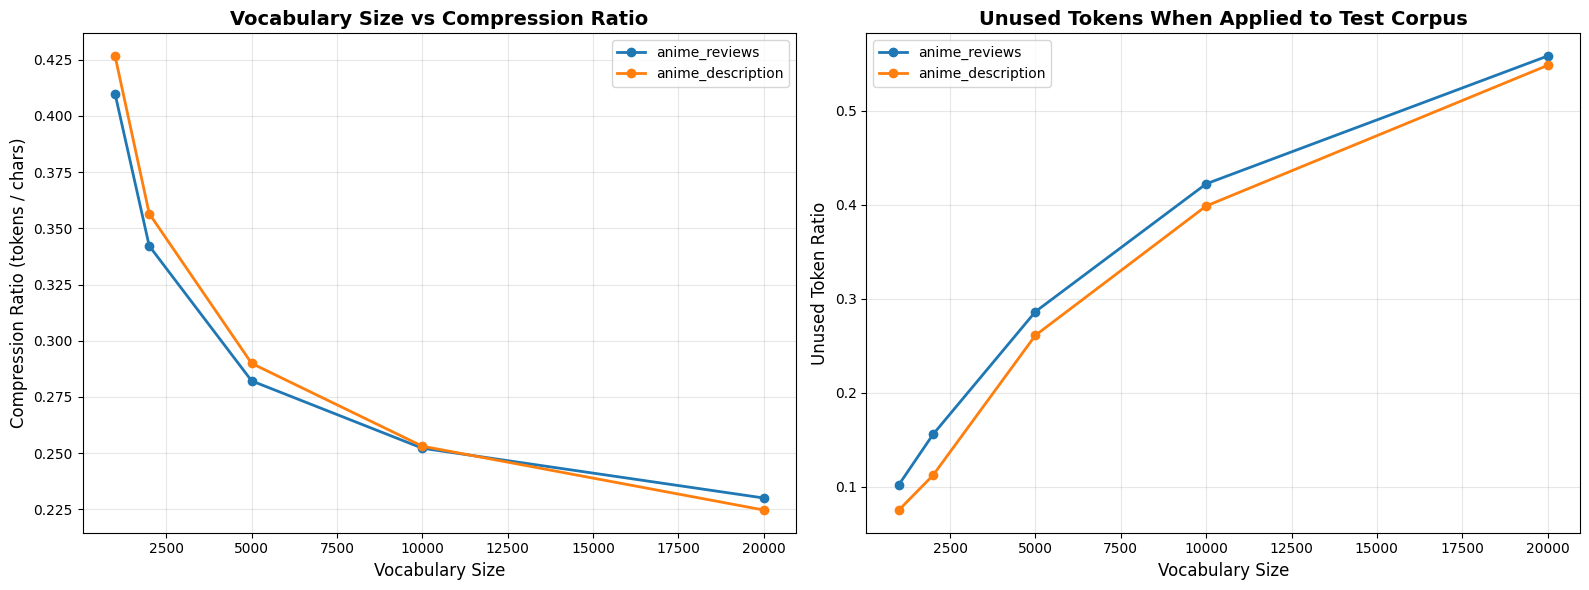

In [15]:
corpora = {
    "anime_reviews": anime_reviews,
    "anime_description": anime_description
}

vocab_sizes = [1000, 2000, 5000, 10000, 20000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
tokenizers = {}

print("Training tokenizers and calculating compression ratios...")
for name, corpus in corpora.items():
    compression_ratios = []
    for vocab_size in vocab_sizes:
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=False
        )
        tokenizer.train_from_iterator([corpus], trainer=trainer)
        encoding = tokenizer.encode(corpus)
        compression_ratio = len(encoding.ids) / len(corpus.replace("\n", ""))
        compression_ratios.append(compression_ratio)
    
    ax1.plot(vocab_sizes, compression_ratios, marker='o', label=name, linewidth=2)

ax1.set_xlabel("Vocabulary Size", fontsize=12)
ax1.set_ylabel("Compression Ratio (tokens / chars)", fontsize=12)
ax1.set_title("Vocabulary Size vs Compression Ratio", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

print("\nAnalyzing unused tokens on test corpus...")
test_corpus = pushkin_poems

for name, corpus in corpora.items():
    unused_ratios = []
    
    for vocab_size in vocab_sizes:
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=False
        )
        tokenizer.train_from_iterator([corpus], trainer=trainer)
        
        encoding = tokenizer.encode(test_corpus)
        vocab = tokenizer.get_vocab()
        used_token_ids = set(encoding.ids)
        unused_tokens = [token for token, idx in vocab.items() if idx not in used_token_ids]
        unused_ratio = len(unused_tokens) / len(vocab)
        unused_ratios.append(unused_ratio)
        
        print(f"{name} - Vocab {vocab_size}: {unused_ratio:.4f} unused")
    
    ax2.plot(vocab_sizes, unused_ratios, marker='o', label=name, linewidth=2)

ax2.set_xlabel("Vocabulary Size", fontsize=12)
ax2.set_ylabel("Unused Token Ratio", fontsize=12)
ax2.set_title("Unused Tokens When Applied to Test Corpus", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Задача 1.1. 3 балла 
- Обучите простую модель (можно RNN/n-gram/transformer) с вашим токенизатором.

In [17]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class TextDataset(Dataset):
    def __init__(self, encodings, seq_len=10):
        self.data = torch.tensor(encodings.ids, dtype=torch.long)
        self.seq_len = seq_len
        
    def __len__(self):
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

class GRU_RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=4, hidden_dim=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.rnn(x)
        x = self.fc(x)
        return x

test_corpus = anime_description
encoding = tokenizer_anime_reviews.encode(test_corpus)
vocab = tokenizer_anime_reviews.get_vocab()

vocab_size = len(vocab)
model = GRU_RNN(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

dataset = TextDataset(encoding)
dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=0, pin_memory=True)

model.train()
for epoch in range(48):
    total_loss = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

def generate(model, tokenizer, prompt, max_len=50):
    model.eval()
    tokens = tokenizer.encode(prompt).ids
    
    for _ in range(max_len):
        x = torch.tensor([tokens[-50:]]).to(device)
        with torch.no_grad():
            output = model(x)
        next_token = output[0, -1].argmax().item()
        tokens.append(next_token)
        
    return tokenizer.decode(tokens)

Epoch 1, Loss: 7.1035
Epoch 2, Loss: 6.4974
Epoch 3, Loss: 6.1349
Epoch 4, Loss: 6.0216
Epoch 5, Loss: 5.9573
Epoch 6, Loss: 5.9124
Epoch 7, Loss: 5.8775
Epoch 8, Loss: 5.8461
Epoch 9, Loss: 5.8191
Epoch 10, Loss: 5.7937
Epoch 11, Loss: 5.7713
Epoch 12, Loss: 5.7514
Epoch 13, Loss: 5.7341
Epoch 14, Loss: 5.7193
Epoch 15, Loss: 5.7072
Epoch 16, Loss: 5.6972
Epoch 17, Loss: 5.6882
Epoch 18, Loss: 5.6800
Epoch 19, Loss: 5.6713
Epoch 20, Loss: 5.6637
Epoch 21, Loss: 5.6578
Epoch 22, Loss: 5.6521
Epoch 23, Loss: 5.6466
Epoch 24, Loss: 5.6414
Epoch 25, Loss: 5.6371
Epoch 26, Loss: 5.6318
Epoch 27, Loss: 5.6282
Epoch 28, Loss: 5.6249
Epoch 29, Loss: 5.6215
Epoch 30, Loss: 5.6187
Epoch 31, Loss: 5.6160
Epoch 32, Loss: 5.6139
Epoch 33, Loss: 5.6117
Epoch 34, Loss: 5.6099
Epoch 35, Loss: 5.6078
Epoch 36, Loss: 5.6063
Epoch 37, Loss: 5.6042
Epoch 38, Loss: 5.6034
Epoch 39, Loss: 5.6014
Epoch 40, Loss: 5.5998
Epoch 41, Loss: 5.5988
Epoch 42, Loss: 5.5983
Epoch 43, Loss: 5.5967
Epoch 44, Loss: 5.59

In [18]:
print(generate(model, tokenizer_anime_reviews, "Это аниме", 30))

 Это аниме, что в его, но в этом-за, но в его, но в этом-за, но в его, но в этом-за


In [19]:
torch.cuda.empty_cache()

## Задача 1.2. 2 балла 
- Замените токенизатор GPT-2 на ваш (обученный на текстах, содержащих русский язык) и дообучите уже предобученный GPT-2 124M на нем.

In [20]:

os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GPT2Dataset(Dataset):
    def __init__(self, encodings, seq_len=256):
        self.data = torch.tensor(encodings.ids, dtype=torch.long)
        self.seq_len = seq_len
        
    def __len__(self):
        return max(0, len(self.data) - self.seq_len)
    
    def __getitem__(self, idx):
        chunk = self.data[idx:idx + self.seq_len + 1]
        x = chunk[:-1]
        y = chunk[1:]
        
        if len(x) < self.seq_len:
            pad_len = self.seq_len - len(x)
            x = torch.cat([x, torch.zeros(pad_len, dtype=torch.long)])
            y = torch.cat([y, torch.zeros(pad_len, dtype=torch.long)])
        
        return x, y

def adapt_gpt2_to_new_tokenizer(model, new_vocab_size, old_vocab_size=50257):
    old_embeddings = model.transformer.wte.weight.data
    old_lm_head = model.lm_head.weight.data
    
    new_embeddings = nn.Embedding(new_vocab_size, model.config.n_embd)
    new_lm_head = nn.Linear(model.config.n_embd, new_vocab_size, bias=False)
    
    min_vocab = min(old_vocab_size, new_vocab_size)
    new_embeddings.weight.data[:min_vocab] = old_embeddings[:min_vocab]
    new_lm_head.weight.data[:min_vocab] = old_lm_head[:min_vocab]
    
    if new_vocab_size > old_vocab_size:
        nn.init.normal_(new_embeddings.weight.data[old_vocab_size:], std=0.02)
        nn.init.normal_(new_lm_head.weight.data[old_vocab_size:], std=0.02)
    
    model.transformer.wte = new_embeddings
    model.lm_head = new_lm_head
    model.config.vocab_size = new_vocab_size
    
    return model

def train_gpt2(model, dataloader, epochs=3, lr=5e-5):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scaler = GradScaler()
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            with autocast(device_type="cuda"):
                outputs = model(input_ids=x, labels=y)
                loss = outputs.loss
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")
        
        print(f"Epoch {epoch+1}, Average Loss: {total_loss/len(dataloader):.4f}\n")

def generate_text(model, tokenizer, prompt, max_length=100, temperature=0.8):
    model.eval()
    tokens = tokenizer.encode(prompt).ids
    input_ids = torch.tensor([tokens]).to(device)
    
    with torch.no_grad():
        for _ in range(max_length):
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            input_ids = torch.cat([input_ids, next_token], dim=-1)
            
            if next_token.item() == tokenizer.token_to_id("<|endoftext|>"):
                break
    
    return tokenizer.decode(input_ids[0].cpu().tolist())

test_corpus = anime_description[:100000]
encoding = tokenizer_anime_reviews.encode(test_corpus)
vocab = tokenizer_anime_reviews.get_vocab()

vocab_size = len(vocab)
model = GPT2LMHeadModel.from_pretrained('gpt2')
model = adapt_gpt2_to_new_tokenizer(model, vocab_size)
model = model.to(device)

dataset = GPT2Dataset(encoding, seq_len=32)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, 
                       num_workers=0, pin_memory=False)

train_gpt2(model, dataloader, epochs=12, lr=5e-5)

prompt = "Аниме про"
generated = generate_text(model, tokenizer_anime_reviews, prompt, max_length=50)
print(f"\n{generated}")

Epoch 1/12, Batch 0, Loss: 11.3072
Epoch 1/12, Batch 10, Loss: 8.2583
Epoch 1/12, Batch 20, Loss: 7.5440
Epoch 1/12, Batch 30, Loss: 7.2977
Epoch 1/12, Batch 40, Loss: 7.1773
Epoch 1/12, Batch 50, Loss: 7.0595
Epoch 1/12, Batch 60, Loss: 7.0709
Epoch 1/12, Batch 70, Loss: 6.9970
Epoch 1/12, Batch 80, Loss: 6.9941
Epoch 1/12, Batch 90, Loss: 6.9968
Epoch 1/12, Batch 100, Loss: 6.9339
Epoch 1/12, Batch 110, Loss: 7.0042
Epoch 1/12, Batch 120, Loss: 6.9312
Epoch 1/12, Batch 130, Loss: 6.9274
Epoch 1/12, Batch 140, Loss: 6.8682
Epoch 1/12, Batch 150, Loss: 6.8239
Epoch 1/12, Batch 160, Loss: 6.7715
Epoch 1/12, Batch 170, Loss: 6.8463
Epoch 1/12, Batch 180, Loss: 6.6948
Epoch 1/12, Batch 190, Loss: 6.7688
Epoch 1/12, Batch 200, Loss: 6.7058
Epoch 1/12, Batch 210, Loss: 6.6401
Epoch 1/12, Batch 220, Loss: 6.5690
Epoch 1/12, Batch 230, Loss: 6.4401
Epoch 1/12, Batch 240, Loss: 6.4909
Epoch 1/12, Batch 250, Loss: 6.4084
Epoch 1, Average Loss: 7.0112

Epoch 2/12, Batch 0, Loss: 6.3397
Epoch 2/1